---
title: Effective Tutorial Notebooks for Cloud Computing Workflows using Remote Sensing Datasets
short_title: Local Notebook
date: 2026-05-14
github: https://github.com/zsk4/USRSE26_Notebook/
subject: Tutorial
authors:
  - name: Zachary Katz
    affiliations:
      - id: CSM
        institution: Colorado School of Mines
        department: Department of Geophysics
    email: zachary_katz@mines.edu
    corresponding: true
    github: zsk4
    orcid: 0009-0006-2779-7103
  - name: Tasha Snow
    affiliations:
      - University of Maryland
      - NASA Goddard Space Flight Center
      - CSM
    email: tsnow03@umd.edu
    orcid: 0000-0001-5697-5470
license: MIT
---

:::{error} 📝 Navigating This Notebook
:icon: false

This version of the notebook has been adapted to run locally using the provided python environment, for example by removing the pip install cloud best practices.

This notebook is adapted from [Comparing SWOT HR Elevation to ICESat-2](https://book.cryointhecloud.com/swot-hr-w-is2/), a tutorial used to help onboard CryoCloud users. We have trimmed content for timing and added callouts with a red sidebar and paper icon like this one to showcase features we added to help make the notebook effective for users starting with cloud computing and large geophysical datasets.

:::

# Overview

:::{error} 📝 Setup
:icon: false
Learning objectives and prerequesites ensure users are on the same page to begin the tutorial.

:::

In this tutorial, we will compare NASA/CNES's Surface Water and Ocean Topography (SWOT) Low Rate raster elevations to NASA’s Ice, Cloud, and Land Elevation Satellite-2 (ICESat-2) ATL06 land ice elevations over the Bach Ice Shelf (Antarctic Peninsula), verifying correct application of geophysical corrections. 

::::{important} Learning Objectives

By the end of this tutorial, you will be able to:

- Obtain spatially coincident ICESat-2 ATL06 land ice and SWOT HR raster elevations
- Correct for differing geophysical corrections between missions  
- Correct for ice advection between acquisitions  
- Plot a comparison of ICESat-2 and SWOT elevations over Bach Ice Shelf
::::

::::{caution} Prerequisites
- [SWOT HR data access tutorial](https://book.cryointhecloud.com/swot-hr-access)
- A free [**Earthdata Login**](https://urs.earthdata.nasa.gov/) to download SWOT and ICESat-2 data
- (Optional) A free [**Aviso+ Login**](https://www.aviso.altimetry.fr/en/data/data-access/registration-form.html) to download a Dynamic Atmospheric Correction (DAC) for correcting SWOT data. Note this may take up to a week to process, so we provide a flag to run the tutorial without the DAC.
- (Optional) Your Earthdata and Aviso+ logins can be stored for programattic access by following the CryoCloud [**Configure Programmatic Access To NASA Servers**](https://book.cryointhecloud.com/earthdata/#configure-programmatic-access-to-nasa-servers) how-to guide.
::::

## Package imports and data paths needed to get started

# Compare SWOT and ICESat-2 elevations on Bach Ice Shelf
From the figure made in the [SWOT HR data access tutorial](https://book.cryointhecloud.com/swot-hr-access), we can see that there is HR coverage over Bach Ice Shelf so we will compare SWOT heights there to ICESat-2. 

```{figure} /Images/SWOT_DataAvailability.png
:width: 80%
:align: center

SWOT Availability over Antarctica
```

ICESat-2 is a photon-counting green laser altimeter. We can make this comparison because when measuring snow and ice surface heights, both SWOT (Ka band radar) and ICESat-2 (photon counting green laser) are considered surface sensing instruments. They penetrate to nearly equivalent depths into snow and ice, though Ka band radar likely penetrates millimeters to a few centimeters deeper into dry snow than ICESat-2 does. They are likely more indistinguishable for wet snow. More information about ICEsat-2 data products, mission, and tutorials is available in the [ICESat-2 Cookbook](https://icesat-2hackweek.github.io/icesat2-cookbook/). 

```{figure} /Images/Smith++2019_Figure1.jpg
:width: 80%
:align: center

ICESat-2 laser configuration (from [Smith and others, 2019](https://doi.org/10.1016/j.rse.2019.111352))
```

We will use what we learned in the [SWOT HR data access tutorial](https://book.cryointhecloud.com/swot-hr-access) to compare the [SWOT_L2_HR_Raster_100m](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3233942298-POCLOUD&pg[0][v]=f&pg[0][gsk]=-start_date&tl=1714336636.163!4!!) product to [ICESat-2's Land Ice Height, Version 7 (ATL06)](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C2670138092-NSIDC_CPRD&pg[0][v]=f&pg[0][gsk]=-start_date&q=icesat-2%20atl06) over a rift on Bach Ice Shelf. 

To demonstrate different `earthaccess` search methods, we search for a specific granule of SWOT data found using [Earthdata search](https://www.earthdata.nasa.gov/) and we search for all ICESAT-2 tracks in a specified bounding box and manually pick one ICESat-2 track that intersects the SWOT swath at our region of interest. 

::::{hint} What you'll do
1. Obtain spatially coincident ICESat-2 ATL06 and SWOT HR data  
2. Apply consistent geophysical corrections across missions
3. Advect ICESat-2 tracks to the SWOT acquisition time using a velocity map
4. Plot map view and cross section comparisons of SWOT and ICESat-2 elevations over a Bach Ice Shelf rift
::::

::::{seealso} Data sources used
The two satellite data products used for elevation comparisons
- [SWOT_L2_HR_Raster_100m](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3233942298-POCLOUD&pg[0][v]=f&pg[0][gsk]=-start_date&tl=1714336636.163!4!!)
- [ICESat-2's Land Ice Height, Version 7 (ATL06)](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C2670138092-NSIDC_CPRD&pg[0][v]=f&pg[0][gsk]=-start_date&q=icesat-2%20atl06)

Geophysical corrections
- [CATS2008_v2023](https://doi.org/10.15784/601772 ) for ocean tide corrections to both SWOT and ICESat-2
- [Aviso+ DAC](https://doi.org/10.24400/527896/a01-2022.001) for Dynamic Atmospheric Corrections to SWOT (DAC is included with ICESAt-2)

Basemap
- [MODIS Mosiac of Antarctica 2008-2009 Image Map, Version 2](https://nsidc.org/data/nsidc-0593/versions/2) from NSIDC
    - <https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0593_moa2009_v02/geotiff/moa750_2009_hp1_v02.0.tif.gz>
- [MEaSUREs Antarctica Ice Velocity](https://nsidc.org/data/nsidc-0484/versions/2) from NSIDC
    - <https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/MEASURES/NSIDC-0484/2/1996/01/01/antarctica_ice_velocity_450m_v2.nc>
- Scripps Antarctica polygons from the supplement of [M.A. Depoorter et al., 2013](https://doi.pangaea.de/10.1594/PANGAEA.819147)
    - <https://doi.pangaea.de/10013/epic.42133.d001>
::::

## Imports, paths, and constants to get started

:::{error} 📝 Abstraction
:icon: false
Hidden dropdowns provide additional information to expert users and users reviewing the tutorial without a leader.

Functions that perform tasks thet do not need to be elaborated on during the tutorial (e.g., coordinate transformations, prettifying plots, date conversions) are provided for reference but stay out of the way.
:::

In [4]:
# --- Imports ---
%matplotlib inline

from pathlib import Path
import datetime as dt
import os, logging, warnings, gzip, shutil, getpass, io

# Data and processing
import s3fs
import rasterio
import requests
import earthaccess
import numpy as np
import xarray as xr
import icesat2_toolkit
from io import BytesIO
import geopandas as gpd
import cartopy.crs as ccrs
from PyAstronomy import pyasl
from scipy.interpolate import RegularGridInterpolator

import pyTMD
import timescale  

# Visualization and Plotting
from cmap import Colormap
import cartopy.crs as ccrs
from pyproj import CRS, Transformer

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# Quiet noisy logs
warnings.filterwarnings("ignore", message=".*ERROR parsing kml Style: No id.*", category=RuntimeWarning)
logging.getLogger("urllib3.connectionpool").setLevel(logging.ERROR)

In [ ]:
# --- Study area and plotting setup--- 

# Locally, we need to manyally download the grounding line shapefile and point to it here:
GL_ZIP_URL = "https://doi.pangaea.de/10013/epic.42133.d001" # url for grounding line download if necessary
DATADIR = Path("/path/to/grounding/line") # Path to Grounding line shapefile
GL_SHP   = DATADIR / "/scripps_antarctica_polygons_v1.shp" # Grounding line shapefile

BBOX = [-1_970_000, 490_000, -1_820_000, 670_000]  # PS71 [EPSG:3031] bounding box for Bach Ice Shelf
RIFT_BBOX = [-1_885_000, 570_000, -1_855_000, 590_000]  # PS71 [EPSG:3031] bounding box for rift of interest

PS71 = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)

tick_label_size = 16
legend_label_size = 18

::::{admonition} Earthaccess Login and basic helpers
:class: tip
We authenticate with **earthaccess** and define a few more helper functions for coordinate transforms and tides.
::::

In [6]:
# --- Earthdata login (interactive once; persists to ~/.netrc) --- 
auth = earthaccess.login(strategy="interactive", persist=True)
assert auth.authenticated, "Earthdata Login failed."

# Choose to use DAC
dac_flag = False

In [7]:
# Coordinate transforms
def xy2ll(x, y):
    """Convert PS71 (EPSG:3031) coordinates to WGS84 (EPSG:4326)"""
    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    xy_to_ll = Transformer.from_crs(crs_xy, crs_ll, always_xy=True)
    lon, lat = xy_to_ll.transform(x, y)
    return lon, lat

def ll2xy(lon, lat):
    """Convert WGS84 (EPSG:4326) coordinates to PS71 (EPSG:3031)"""
    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y

def ps712utm(x, y, crs):
    """Convert UTM zone {crs} (SWOT native) to PS71 (EPSG:3031) coordinates"""
    crs_utm = CRS(f"EPSG:{crs}")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_xy, crs_utm, always_xy=True)
    utmx, utmy = ll_to_xy.transform(x, y)
    return utmx, utmy

def ensure_scripps_polygons(gl_shp_path: Path, source_zip_url: str) -> None:
    """Download & extract the Scripps Antarctica polygons if missing."""
    if gl_shp_path.exists():
        return
    gl_shp_path.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading Scripps Antarctica polygons…")
    content = download_bytes(source_zip_url)
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        zf.extractall(gl_shp_path.parent)
    print(f"Extracted to: {gl_shp_path.parent}")

# Colorbar Logic
def add_inset_colorbar(fig, ax, mappable, label,
                       anchor=(0.999, 0.90),  # (x, y) in axes fraction
                       width=3.0, height=0.9,  # inches
                       orientation="horizontal", extend=None, fontsize=tick_label_size):
    """ Adds colorbar as an inset to a plot"""
    # outer box (absolute size in inches, 2-tuple anchor is OK)
    cbbox = inset_axes(ax, width=width, height=height,
                       bbox_to_anchor=anchor, bbox_transform=ax.transAxes, loc="upper right")
    
    for sp in cbbox.spines.values():
        sp.set_visible(False)
    cbbox.set_facecolor([0, 0, 0, 0.7])
    cbbox.set_xticks([]); cbbox.set_yticks([])

    # actual bar inside
    inner = inset_axes(cbbox, "92%", "20%", loc="center")
    cbar = fig.colorbar(mappable, cax=inner, orientation=orientation, extend=extend)
    cbar.outline.set_edgecolor("white"); cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=fontsize, color="white", labelcolor="white")
    cbar.set_label(label, fontsize=fontsize+2, color="white")
    if orientation == "horizontal":
        cbar.ax.xaxis.set_label_position("top")
    cbar.ax.minorticks_on(); cbar.ax.tick_params(which="minor", length=4, color="white")
    return cbar

def date_to_julian1950(date):
    """
    Convert datetime object to Julian days since 1950-01-01.
    """
    base_date = dt.datetime(1950, 1, 1)
    current_date = date
    delta = current_date - base_date
    return delta.days + delta.seconds / 86400.0 # include fractional days if needed

def round_to_6hr(julian_day):
    """
    Round fractional Julian day (since 1950-01-01) to the nearest 6-hour mark.
    
    Returns:
        rounded_day (int): Julian day since 1950-01-01 (integer)
        hour (int): Hour of day (0, 6, 12, 18)
    """
    day_int = np.floor(julian_day).astype(int)
    frac_day = julian_day - day_int

    hours = frac_day * 24 #hrs
    rounded_hour = int(round(hours / 6) * 6)

    # Handle rollover
    if rounded_hour == 24:
        rounded_hour = 0
        day_int += 1

    return day_int, rounded_hour


::::{tip} Load Mosaic of Antarctica (MOA) and MEaSUREs Antarctica Ice Velocity basemaps 
We'll use MOA and MEaSUREs Antarctica Ice Velocity as the basemaps for our plots. The ice velocity map will also aid our advection corrections.
::::

:::{note .dropdown} Streaming: No download needed!
Because MOA, MEaSUREs, and many of the datasets we'll use cloud-friendly formats (.tif) and stored using the best data practices (no authentication, CAPTCHA, or other barriers), we can use python to quickly read this data directly into memory without the need to download. Other datasets are not streamable and will require a local copy.
:::

In [8]:
# --- MOA 2009 grayscale basemap (gzipped GeoTIFF) ---

# URL of protected moa file
moa_url = "https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0593_moa2009_v02/geotiff/moa750_2009_hp1_v02.0.tif.gz"

# Use Earthdata login stored in ~/.netrc
session = requests.Session()
session.auth = requests.utils.get_netrc_auth(moa_url)

# Add user-agent to mimic a real browser
headers = {"User-Agent": "NASA Earthdata Python client"}

# Download and check for success
response = session.get(moa_url, headers=headers)
response.raise_for_status()

# Confirm content-type is not HTML (debug print)
if b"<html" in response.content[:100].lower():
    raise RuntimeError("Download returned HTML (login failed or wrong credentials?)")

# Decompress the GZip in memory
with gzip.GzipFile(fileobj=BytesIO(response.content)) as gz:
    tif_bytes = BytesIO(gz.read())

# Read with Rasterio from memory
with rasterio.MemoryFile(tif_bytes) as memfile:
    with memfile.open() as moa:
        bounds = moa.bounds
        left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
        moa_dat = moa.read(1)

ext = (left, right, bottom, top)

In [9]:
# --- Stream MeASUREs ice velocity data via earthaccess (NSIDC-0484), 450 m grid ---

v_results = earthaccess.search_data(short_name="NSIDC-0484", 
                                    cloud_hosted=True,
                                    temporal=("1996-01-01","1996-01-02"), 
                                    count=1)

v_file = earthaccess.open(v_results)[0]
vel = xr.open_dataset(v_file)

# Crop a margin around our box; compute magnitude for plotting
off = 10_000
v_crop = vel.sel(x=slice(BBOX[0]-off, BBOX[2]+off),
                 y=slice(BBOX[3]+off, BBOX[1]-off))
vel_mag = np.hypot(v_crop.VX, v_crop.VY)  # m/yr
oslo = Colormap("crameri:oslo").to_matplotlib() # Velocity colormap

/home/zkatz/Research/USRSE26_Notebook/.venv/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/home/zkatz/Research/USRSE26_Notebook/.venv/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

::::{tip} Read the Scripps Antarctic basemap
This basemap is an example of a file that is not readily streamable. We will download it locally for our use.
- Auto download the file if not already present (We did this for you on CryoCloud, but provide code for re-download or local use).
- Load the Scripps polygons and reproject to EPSG:3031.  
- Split **grounded ice** and **ice shelves** for map styling.
::::

In [10]:
# Ensure basemap (Scripps polygons) is available
ensure_scripps_polygons(GL_SHP, GL_ZIP_URL)

# Load and prep Scripps polygons
gl_gdf = gpd.read_file(GL_SHP)
# Reproject to EPSG:3031 (Antarctic Polar Stereographic)
gl_gdf_3031 = gl_gdf.to_crs(epsg=3031)

# Split polygons containing grounded ice vs ice shelves
name_field = "Id_text" if "Id_text" in gl_gdf_3031.columns else None
if name_field is None:
    # Fall back to plotting all polygons uniformly if classification is missing
    grounded_3031 = gl_gdf_3031
    shelves_3031 = gpd.GeoDataFrame(geometry=[])
else:
    # Split polygons by class
    grounded_classes = {"Grounded ice or land", "Isolated island", "Ice rise or connected island"}
    grounded_3031 = gl_gdf_3031[gl_gdf_3031[name_field].isin(grounded_classes)]
    shelves_3031  = gl_gdf_3031[gl_gdf_3031[name_field] == "Ice shelf"]

::::{tip} Get SWOT HR & determine ICESat-2 search window
We stream one SWOT_L2_HR_Raster_100m_D granule chosen over Bach Ice Shelf, then search ICESat-2 ATL06 within ± 9 days and within the box. We'll use the results of our ATL06 search to select one track crossing our rift of interest
::::

:::{error} 📝 Showcasing User Options
:icon: false
One learning outcome of this notebook is to familiarize users with different data access schemes using ```earthaccess```. We provide two schemes for downloading our two main datasets (granule name and spatiotemporal search) and provide other search tools in comments.
:::

In [11]:
# --- SWOT HR granule (search via granule name) ---
search_days = 9

# Search for SWOT with specific raster granule name
swot_results = earthaccess.search_data(
    short_name="SWOT_L2_HR_Raster_D",
    temporal=("2025-05-23", "2025-05-23"),
    granule_name="SWOT_L2_HR_Raster_100m_UTM18D_N_x_x_x_033_143_012F_20250523T232533_20250523T232551_PID0_01.nc",
)
swot_file = earthaccess.open(swot_results)[0]
ds_swot = xr.open_dataset(swot_file, engine="h5netcdf")

# Build LAT/LON polygon for ATL06 search
poly_xy = np.array([[RIFT_BBOX[0], RIFT_BBOX[1]],[RIFT_BBOX[2], RIFT_BBOX[1]],
                    [RIFT_BBOX[2], RIFT_BBOX[3]],[RIFT_BBOX[0], RIFT_BBOX[3]],[RIFT_BBOX[0], RIFT_BBOX[1]]])
poly_lon, poly_lat = xy2ll(poly_xy[:,0], poly_xy[:,1])
polygon_ll = np.c_[poly_lon, poly_lat].tolist()

# Time window: SWOT start/end ± 9 days
t0 = dt.datetime.strptime(ds_swot.time_granule_start, "%Y-%m-%dT%H:%M:%S.%fZ")
t1 = dt.datetime.strptime(ds_swot.time_granule_end,   "%Y-%m-%dT%H:%M:%S.%fZ")
atl06_window = (t0 - dt.timedelta(days=search_days), t1 + dt.timedelta(days=search_days))

# Search for all ICESat-2 tracks within a spatial and temporal window
atl06_results = earthaccess.search_data(short_name="ATL06",
                                        temporal=atl06_window,
                                        polygon=polygon_ll)
print(f'{len(atl06_results)} files found in time window in RIFT_BBOX')

/home/zkatz/Research/USRSE26_Notebook/.venv/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/home/zkatz/Research/USRSE26_Notebook/.venv/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

3 files found in time window in RIFT_BBOX


/home/zkatz/Research/USRSE26_Notebook/.venv/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


::::{tip} Read ATL06 beams
We’ll stream just the ATL06 variables we need from each file using `h5netcdf` + `s3fs` temporary credentials from **earthaccess**.
::::

In [12]:
# --- Read a subset of ATL06 beams and variables - 30 s ---
beam_roots = ["gt1l","gt1r","gt2l","gt2r","gt3l","gt3r"]

s3_creds = auth.get_s3_credentials(daac="NSIDC")
fs_nsidc = s3fs.S3FileSystem(
    key=s3_creds["accessKeyId"],
    secret=s3_creds["secretAccessKey"],
    token=s3_creds["sessionToken"],
)

def read_atl06_points(result):
    """Return a list of dicts (one per beam) with coords, heights, corrections."""
    out = []
    files = earthaccess.open(
        [result.data_links()[0]],
        open_kwargs={
            "cache_type": "blockcache",
            "block_size": 4 * 1024 * 1024,
        },
    )
    file_to_open = files[0]
    s3_url = result.data_links(access="direct")[0].replace("s3://","")
    for beam in beam_roots:
        try:
                ds_main = xr.open_dataset(file_to_open, engine="h5netcdf",
                                          group=f"{beam}/land_ice_segments",
                                          driver_kwds={"rdcc_nbytes": 1024*1024},
                                          decode_times=False, phony_dims="sort")
                ds_dem  = xr.open_dataset(file_to_open, engine="h5netcdf",
                                          group=f"{beam}/land_ice_segments/dem",
                                          driver_kwds={"rdcc_nbytes": 1024*1024},
                                          decode_times=False, phony_dims="sort")
                ds_geo  = xr.open_dataset(file_to_open, engine="h5netcdf",
                                          group=f"{beam}/land_ice_segments/geophysical",
                                          driver_kwds={"rdcc_nbytes": 1024*1024},
                                          decode_times=False, phony_dims="sort")
                data = {
                    "lon": ds_main["longitude"].values,
                    "lat": ds_main["latitude"].values,
                    "h_li": ds_main["h_li"].values.astype("float32"),
                    "t_dt": ds_main["delta_time"].values,
                    "q":    ds_main["atl06_quality_summary"].values,
                    "geoid_h": ds_dem["geoid_h"].values.astype("float32"),
                    "geoid_free2mean": ds_dem["geoid_free2mean"].values.astype("float32"),
                    "tide_ocean": ds_geo["tide_ocean"].values.astype("float32"),
                    "dac": ds_geo["dac"].values.astype("float32"),
                    "tide_earth": ds_geo["tide_earth"].values.astype("float32"),
                    "tide_earth_free2mean": ds_geo["tide_earth_free2mean"].values.astype("float32"),
                    "tide_pole": ds_geo["tide_pole"].values.astype("float32"),
                    "tide_load": ds_geo["tide_load"].values.astype("float32"),
                    "beam": beam, "name": s3_url,
                }
                # Mask poor quality data
                bad = (data["q"] == 1) | (data["h_li"] > 3.0e38)
                data["h_li"][bad] = np.nan
                # PS71 coords
                data["x"], data["y"] = ll2xy(data["lon"], data["lat"])
                out.append(data)
        except Exception as exc:
            # Skip missing beams
            print(f"{s3_url} | {beam}: {type(exc).__name__}: {exc}")
            continue
    return out

atl06 = []
for r in atl06_results:
    atl06.extend(read_atl06_points(r))

# Convert delta_time -> decimal years using icesat2_toolkit
for d in atl06:
    dec = icesat2_toolkit.convert_delta_time(d["t_dt"])
    d["time"] = dec["decimal"]

print(f'{len(atl06)} beams loaded')

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

18 beams loaded


### Preview and choose ATL06 tracks to compare with SWOT

:::{error} 📝 Interactivity
:icon: false
Interactice sections help users become familiar with different choices, but the notebook is written to work without changing anything to allow users to complete the tutorial without a leader.
:::

We’ll plot the `atl06` candidates on top of the SWOT swath and the MOA background map. 

Use the `is2_start`/`is2_end` indices to step through candidates until you find a track that best crosses your area of interest (e.g., the crevasse field). The cell prints the **granule filename** and **beam** for each plotted candidate so you can note the one you want to use in the next step.

::::{tip} Tips
- Start with the full range and then narrow in using the ICESat-2 colormap to determine which track you want.  
- If the panel looks empty, verify the indices chosen are within `len(atl06)`.  
::::

Previewing ATL06 candidates [0:18] out of total 18
gt1l  ATL06_20250515130244_09102710_007_01.h5
gt1r  ATL06_20250515130244_09102710_007_01.h5
gt2l  ATL06_20250515130244_09102710_007_01.h5
gt2r  ATL06_20250515130244_09102710_007_01.h5
gt3l  ATL06_20250515130244_09102710_007_01.h5
gt3r  ATL06_20250515130244_09102710_007_01.h5
gt1l  ATL06_20250520014201_09792712_007_01.h5
gt1r  ATL06_20250520014201_09792712_007_01.h5
gt2l  ATL06_20250520014201_09792712_007_01.h5
gt2r  ATL06_20250520014201_09792712_007_01.h5
gt3l  ATL06_20250520014201_09792712_007_01.h5
gt3r  ATL06_20250520014201_09792712_007_01.h5
gt1l  ATL06_20250524013336_10402712_007_01.h5
gt1r  ATL06_20250524013336_10402712_007_01.h5
gt2l  ATL06_20250524013336_10402712_007_01.h5
gt2r  ATL06_20250524013336_10402712_007_01.h5
gt3l  ATL06_20250524013336_10402712_007_01.h5
gt3r  ATL06_20250524013336_10402712_007_01.h5


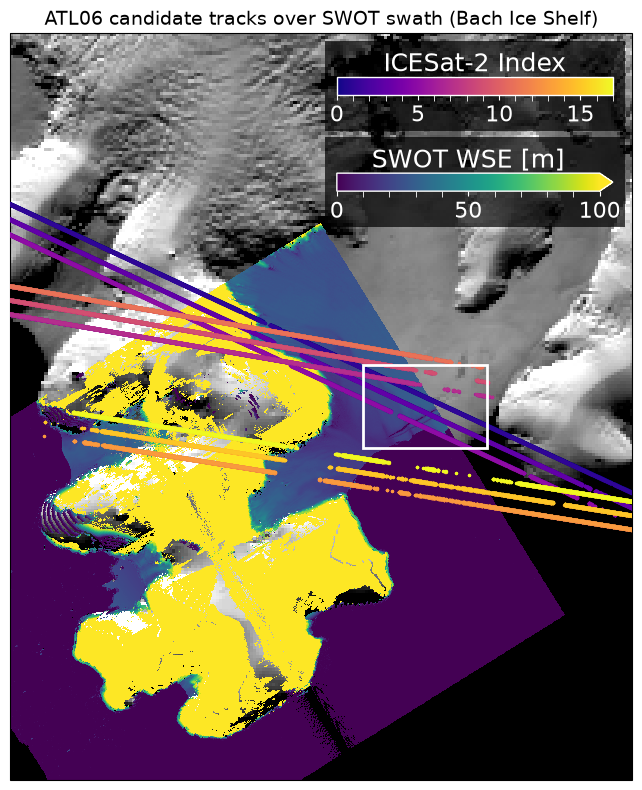

In [13]:
# --- Choose a slice of ATL06 candidates to preview (adjust as needed) ---
is2_start, is2_end = 0, 18  # tweak these indices

subset = atl06[is2_start:is2_end]
print(f"Previewing ATL06 candidates [{is2_start}:{is2_end}] out of total {len(atl06)}")
for d in subset:
    print(f"{d['beam']:>4}  {d['name'].split('/')[-1]}")

# --- Figure: MOA (gray) + SWOT swath (viridis) + ATL06 points ---
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=PS71)

# MOA basemap
ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)

# SWOT swath (water surface elevation)
wse = ds_swot["wse"]
utm = ccrs.UTM(zone=ds_swot.utm_zone_num, southern_hemisphere=True)
X, Y = np.meshgrid(wse["x"].values, wse["y"].values)
mesh = ax.pcolormesh(
    X, Y, wse.values,
    transform=utm, cmap="viridis", shading="auto",
    vmin=0, vmax=100, zorder=2
)

# ATL06 candidate tracks (colored by index within the slice)
cmap = plt.get_cmap("plasma")
n = max(1, len(subset))
for i, d in enumerate(subset):
    color = cmap(i / (n - 1) if n > 1 else 0.5)
    ax.scatter(d["x"], d["y"], s=2, color=color, transform=PS71, zorder=3)
# Convert cmap into ScalarMappable for colorbar
norm = plt.Normalize(vmin=0, vmax=n - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

bach_rect = plt.Rectangle((RIFT_BBOX[0], RIFT_BBOX[1]), RIFT_BBOX[2] - RIFT_BBOX[0], RIFT_BBOX[3] - RIFT_BBOX[1], 
                          zorder=5, linewidth=2, edgecolor="white", facecolor="none")
ax.add_patch(bach_rect)

# View & labels
ax.set_xlim(BBOX[0], BBOX[2])
ax.set_ylim(BBOX[1], BBOX[3])
ax.set_title("ATL06 candidate tracks over SWOT swath (Bach Ice Shelf)", fontsize=14)

# Colorbar for SWOT Swath
add_inset_colorbar(fig, ax, mesh, "SWOT WSE [m]", anchor=(0.999, 0.87), extend="max")
# ICESat-2 tracks colorbar
add_inset_colorbar(fig, ax, sm, "ICESat-2 Index", anchor=(0.999, 0.999))

plt.tight_layout()
plt.show()

::::{tip} Pick a ICESat-2 track and advect it to SWOT time
We’ll select a beam/granule that crosses the crevasse field and advect the ICESat-2 points to the SWOT acquisition time using the MEaSUREs ice velocity grid.
::::

In [14]:
# --- Find granule matching ATL06_20241213201922_13522510_006_01.h5 --- 

# Try replacing gran and beam with your chosen granule and beam
gran = 'ATL06_20250515130244_09102710_007_01.h5'
beam = 'gt2r'
is2_tracks_to_use = []
for i, data in enumerate(atl06):
    if gran in data['name'] and beam in data['beam']:
        is2_tracks_to_use.append(atl06[i])

assert is2_tracks_to_use, 'No tracks found' # Check at least one track chosen

::::{note} Notes on advection
- Create regular grid interpolators to speed up running the advection code
- Advect ICESat-2 to location at time of SWOT data collection using velocity model resolution
- We only run for one ICESat-2 track, but you could also process multiple at once
::::

In [15]:
# --- Advect ICESat-2 to location at time of SWOT data collection ---

# Create regular grid interpolators to speed up running the advection code (~10x speed up over using native grid)
def prep_velocity_interpolators(vel):
    vx_interp = RegularGridInterpolator((vel.y.values[::-1], vel.x.values),
                        vel["VX"].values[::-1, :],bounds_error=False,fill_value=np.nan)
    vy_interp = RegularGridInterpolator((vel.y.values[::-1], vel.x.values),
                        vel["VY"].values[::-1, :],bounds_error=False,fill_value=np.nan)
    return vx_interp, vy_interp

for track in is2_tracks_to_use:
    # Copy arrays so we don't mutate the originals
    start_x = track["x"].copy()
    start_y = track["y"].copy()
    start_time = track["time"].copy()      # decimal years (one per point)

    # Spatial mask to the study bounding box (BBOX: [xmin, ymin, xmax, ymax])
    mask = (
        (start_x > BBOX[0]) &
        (start_x < BBOX[2]) &
        (start_y > BBOX[1]) &
        (start_y < BBOX[3])
    )
    # Keep full array length; mark points outside the box as NaN in X
    # (Y is left unchanged to preserve indexing; NaNs in X will propagate during updates)
    start_x[~mask] = np.nan

    # Convert decimal year → Python datetime for each sample
    start_time = [pyasl.decimalYearGregorianDate(t) for t in start_time]

    # Integration setup
    target_time = t0 - dt.timedelta(days=0)   # SWOT target time (t0); minus 0 keeps semantics
    step_size = 1 / 365                       # years per step (1 day)

    # For each point, compute time difference to target, then number of steps
    steps = [(target_time - t) for t in start_time]  # list of timedeltas (can be ±)
    steps = [int( td.total_seconds() / (365 * 24 * 60 * 60) / step_size ) for td in steps]
    
    # Use the sign of the FIRST point's step count to set direction (forward or backward in time)
    step_size = np.sign(steps[0]) * step_size
    # Integrate a UNIFORM number of steps for all points (assumes similar times)
    steps = np.abs(steps)

    # Velocity interpolators on the cropped grid
    # v_crop has coordinates (y, x). Arrays are stored row-major with y decreasing,
    # so the helper flips y when building RegularGridInterpolator.
    vx_interp, vy_interp = prep_velocity_interpolators(v_crop)

    # Euler integration (meters per year * years per step = meters per step)
    x = start_x.copy()
    y = start_y.copy()
    for _ in range(steps[0]):                 # same number of steps for every point
        # Sample velocity at current positions; inputs are (y, x)
        vx = vx_interp((y, x))                # meters / year
        vy = vy_interp((y, x))
        # Update positions; NaNs remain NaN and will propagate
        x = x + vx * step_size
        y = y + vy * step_size

    # Store advected coordinates back on the track
    track["x_advected"] = x
    track["y_advected"] = y

## Apply comparable geophysics & interpolate SWOT along-track

We bring heights to a consistent reference, then interpolate the SWOT corrected elevations to the advected ICESat-2 points

::::{admonition} Tide corrections from CATS2008
:class: tip
ICESat-2 and SWOT provide elevations at different tidal heights because the data was collected at different times. We model the tides at the time of acquisition from both SWOT and ICESat-2 and subtract the tide elevation from the data to ensure a fair comparison. 

We use the CATS2008-v2023 tide model to correct for tides in SWOT and ICESat-2. CATS2008 is a circum-Antarctic high-resolution regional inverse ocean model. The model accounts for ocean cavities under the floating ice shelves so it performs more accurately that other tide models around Antarctica.

PyTMD is the python library that runs the model. PyTMD needs a local copy of the model grid. We fetch it once from the public S3 bucket and place it in PyTMD’s data path.
::::

In [22]:
# --- Ensure CATS2008-v2023 is available locally for PyTMD ---
fs = s3fs.S3FileSystem(anon=True)
pyTMD_path = pyTMD.utilities.get_data_path("data")
model = pyTMD.io.model(pyTMD_path, verify=False).elevation("CATS2008-v2023")
model.grid_file.parent.mkdir(parents=True, exist_ok=True)

# Reworked streaming of CATS2008-v2023
s3_path = "pytmd/CATS2008_v2023/CATS2008_v2023.nc"

with fs.open(s3_path, "rb") as fin:
    with open(model.grid_file, "wb") as fout:
        shutil.copyfileobj(fin, fout, length=16 * 1024 * 1024)

print(f"{model.grid_file.stat().st_size / 1e9:.2f} GB")

1.78 GB


::::{admonition} Computing tide corrections
:class: tip
We compute tides in two steps that we have put into this helper function `compute_tides` which sets up the model and then predicts the tides and their minor consituents for each latitude/longiutde pair provided.
::::

In [23]:
# Tides
def compute_tides(model, lons, lats, datetimes):
    """
    Computes the tides at given locations and times using PyTMD.

    Parameters
    model: PyTMD.model
         Tide model
    lons: list[float]
         Geodetic longitude in EPSG:4326
    lats: list[float]
         Geodetic latitude in EPSG:4326
    datetimes: list[datetime.datetime]
         Datetime to calculate tides

    Returns
    tides - list[float]
         Tide elevations in cm at locations and times sepcified
    """
    years  = np.array([d.year for d in datetimes])
    months = np.array([d.month for d in datetimes])
    days   = np.array([d.day for d in datetimes])
    hours  = np.array([d.hour for d in datetimes])
    minutes= np.array([d.minute for d in datetimes])

    tide_time = timescale.time.convert_calendar_dates(years, months, days, hours, minutes)

    # Setup model
    constituents = pyTMD.io.OTIS.read_constants(model.grid_file, model.model_file,
                                         model.projection, type=model.type,
                                         grid=model.format, apply_flexure=False)
    c = constituents.fields
    amp, ph, _ = pyTMD.io.OTIS.interpolate_constants(np.atleast_1d(lons),
                                                     np.atleast_1d(lats), constituents,
                                                     type=model.type, method="spline",
                                                     extrapolate=True)
    cph = -1j * ph * np.pi / 180.0
    hc = amp * np.exp(cph)

    # Calculate tides and infer minor constitutents at each location and time
    tides = []
    for i in range(len(datetimes)):
        TIDE = pyTMD.predict.map(tide_time[i], hc, c, deltat=0, corrections=model.format)
        MINOR = pyTMD.predict.infer_minor(tide_time[i], hc, c, deltat=0, corrections=model.format)
        t_cm = (TIDE.data + MINOR.data) * 100.0
        tides.append(t_cm.astype("float32"))
    return np.array(tides) 

In [24]:
# --- Find tide corrections using CATS at times of interest - 2 min --- 

# Swot and ICESat-2 times
tide_times = [
    t0,
    pyasl.decimalYearGregorianDate(is2_tracks_to_use[0]["time"][0]),
]
sats = ["SWOT", "IS2"]
data = is2_tracks_to_use[0]
data["lon_advected"], data["lat_advected"] = xy2ll(data["x_advected"], data["y_advected"])

for tide_time, satellite in zip(tide_times, sats):
    tide_results = np.array(
        compute_tides(model, data["lon_advected"], data["lat_advected"], [tide_time])).T
    data[f"tide_{satellite}"] = tide_results

data["tide_IS2"] = data["tide_IS2"].astype("float32").squeeze()
data["tide_SWOT"] = data["tide_SWOT"].astype("float32").squeeze()

::::{tip} SWOT Dynamic Atmospheric Correction
Stream AVISO's Dynamic Atmospheric Correction (DAC) for the time of our tile of interest and apply it to the SWOT elevation.
::::

In [25]:
# --- Aviso login if using Dynamic Atmosphere Correction (DAC) (or manually save to ~/.netrc) ---
user = input("AVISO username: ")
pwd = getpass.getpass("AVISO password: ")
session_aviso = requests.Session()
session_aviso.auth = (user, pwd)

In [26]:
# Stream DAC and crop
swot_time = tide_times[0]
year = swot_time.year
julian_day = date_to_julian1950(swot_time)

day, hour = round_to_6hr(julian_day)
if hour == 0:
    hour = '00'
elif hour == 6:
    hour = '06'
elif hour == 12:
    hour = '12'
elif hour == 18:
    hour = '18'
else:
    raise ValueError("Hour rounding error")

try:
    url = (
        f"https://tds-odatis.aviso.altimetry.fr/thredds/fileServer/"
        f"dataset-auxiliary-dynamic-atmospheric-correction/{year}/"
        f"dac_dif_{day}_{hour}.nc"
    )
    print(url)
    r = session_aviso.get(url)
    r.raise_for_status()
    
    dac_corr = xr.open_dataset(io.BytesIO(r.content))

    # Clip to bbox
    dac_corr = dac_corr.sel(latitude=slice(-90, -60)) 
    # Convert from -180 to 180 system to 0 to 360 system to match SWOT
    dac_corr = dac_corr.assign_coords(
        longitude=((dac_corr.longitude + 180) % 360) - 180
    )
    
    lon = dac_corr["longitude"].values
    lat = dac_corr["latitude"].values

    # If lon/lat are 1D, make 2D meshgrid
    if lon.ndim == 1 and lat.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
    else:
        lon2d, lat2d = lon, lat

    x, y = ll2xy(lon2d, lat2d)

    # Add projected coords to dataset
    dac_corr = dac_corr.assign_coords({"x_PS71": (("latitude", "longitude"), x),
                                    "y_PS71": (("latitude", "longitude"), y)})

    # Now clip to bounding box in projected coordinates
    # bbox = [xmin, ymin, xmax, ymax]
    xmin, ymin, xmax, ymax = BBOX
    #dac_corr = dac_corr.where(
    #    (dac_corr["x_PS71"] >= xmin) & (dac_corr["x_PS71"] <= xmax) &
    ##    (dac_corr["y_PS71"] >= ymin) & (dac_corr["y_PS71"] <= ymax),
     #   drop=True
    #)

    # Apply interpolated DAC correction to SWOT

    dac_on_swath = dac_corr['dac'].interp(
    latitude=xr.DataArray(ds_swot['latitude'], dims=('y', 'x')),
    longitude=xr.DataArray(ds_swot['longitude'], dims=('y', 'x')),
    method='linear'
    )

    ds_swot['dac_correction'] = dac_on_swath.reset_coords(drop=True)

except OSError as e:
    print(e)
    print(f'Could not open {url}')

    ds_swot['dac_correction'] = xr.full_like(ds['wse'], '0')


https://tds-odatis.aviso.altimetry.fr/thredds/fileServer/dataset-auxiliary-dynamic-atmospheric-correction/2025/dac_dif_27537_00.nc


::::{tip} Geophysical corrections to ICESat-2 for fair comparison to SWOT
In Version D, SWOT HR Raster variable ```wse``` has the following corrections applied:
```python
wse = H - geoid_height - solid_earth_tide - load_tide - pole_tide
```
where H is the surface elevation above the WGS84 reference ellipsoid. Additionally, we apply the DAC correction to get
```python
wse_dac = wse - dac_correction
```

To compare to SWOT, ICESat-2 ATL06 Version 7 elevation ```h_li``` does not include the geoid correction and DAC by default. Furthermore because the SWOT geoid is in the mean tide system while the ICESat-2 is in the free tide system, we need to apply free2mean corrections. We apply the following corrections to ```h_li```:
```python
h_li_dac = h_li - (geoid_h + geoid_free2mean) - tide_earth_free2mean - dac
```

Use these links for more information about geophysical corrections for [SWOT](https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-docs/web-misc/swot_mission_docs/pdd/D-56416_SWOT_Product_Description_L2_HR_Raster_20250224a_RevC_clean_sig_final.pdf) and [ICESat-2](https://nsidc.org/sites/default/files/documents/technical-reference/icesat2_atl03_atbd_v007.pdf). See also this [excellent reference](https://nsidc.org/sites/default/files/documents/technical-reference/icesat2_comparison-guide_r007.pdf) about comparing ICESat-2 with SWOT. Note that ICESat-2 and SWOT compute some of their geophysical corrections differently, making this comparison not perfect. The proper corrections will also evolve as product versions change.

Ocean tide corrections will be applied after interpolation.
::::

In [27]:
# --- Apply geophysical corrections to ICESat-2 heights for fair comparison to SWOT --- 
data["h_li_dac"] = (
    data["h_li"]
    - (data["geoid_h"] + data["geoid_free2mean"])
    + data["tide_earth_free2mean"]
    - data["dac"]) # Subtract to include, ATL06 v007 ATBD, section 4.3.1

In [28]:
# --- Interpolate SWOT swath along icesat-2 track --- 

# Create arrays to hold interpolated values
overall_wse = np.zeros_like(data["x_advected"])
overall_wse[:] = np.nan
overall_wse_sigma = np.zeros_like(data["x_advected"])
overall_wse_sigma[:] = np.nan

wse = ds_swot["wse"]
wse_sigma = ds_swot["wse_uncert"]

# Convert icesat2 to utm, and interpolate SWOT advected data
x_utm = wse["x"].values
y_utm = wse["y"].values
advected_x_utm, advected_y_utm = ps712utm(data["x_advected"], data["y_advected"], utm.to_epsg())

advected_x_utm = xr.DataArray(advected_x_utm, dims=["points"])
advected_y_utm = xr.DataArray(advected_y_utm, dims=["points"])

x_utm = wse["x"].values
y_utm = wse["y"].values

interpolated_wse = wse.interp(
    x=advected_x_utm,
    y=advected_y_utm,
    method="linear",
    kwargs={"fill_value": np.nan},
).compute()
interpolated_wse_sigma = wse_sigma.interp(
    x=advected_x_utm,
    y=advected_y_utm,
    method="linear",
    kwargs={"fill_value": np.nan},
).compute()

#Put all non-nan values into overall_wse
# If there are no SWOT data values where we have IS2 data, add a nan 
mask = np.isnan(overall_wse) & ~np.isnan(interpolated_wse)
# Only update at those places
overall_wse[mask] = interpolated_wse[mask]
overall_wse_sigma[mask] = interpolated_wse_sigma[mask]

# Compute +- 2 std
lower = overall_wse - 2 * overall_wse_sigma
upper = overall_wse + 2 * overall_wse_sigma

# Cropping data to the rift plot area
min_mask = -1872000
max_mask = -1865000
x_mask = (data["x_advected"] > min_mask) & (
    data["x_advected"] < max_mask
)

::::{tip} Full geophysical corrections applied
In the cell below, we apply the ocean tide correction. This makes the full corrections:

In Version D, SWOT HR Raster variable ```wse``` has the following corrections applied:
```python
swot_corrected = H - geoid_height - solid_earth_tide - load_tide - pole_tide - dac_correction - ocean_tide
```
and
```python
is2_corrected = h_li - (geoid_h + geoid_free2mean) - tide_earth_free2mean - dac - ocean_tide
```
::::

In [29]:
# --- Apply tide corrections to both datasets and uncertainty bounds ---
data["is2_corrected"] = data["h_li_dac"] - data["tide_IS2"] / 100
data["swot_corrected"] = overall_wse - data["tide_SWOT"] / 100
data["swot_lower"] = lower - data["tide_SWOT"] / 100
data["swot_upper"] = upper - data["tide_SWOT"] / 100

::::{tip} Plot map and cross section
We’ll show a map of the advected ICESat-2 track crossing the chosen SWOT granule and a cross-section comparing corrected heights for the section of ICESat-2 track in orange on the map. 
::::

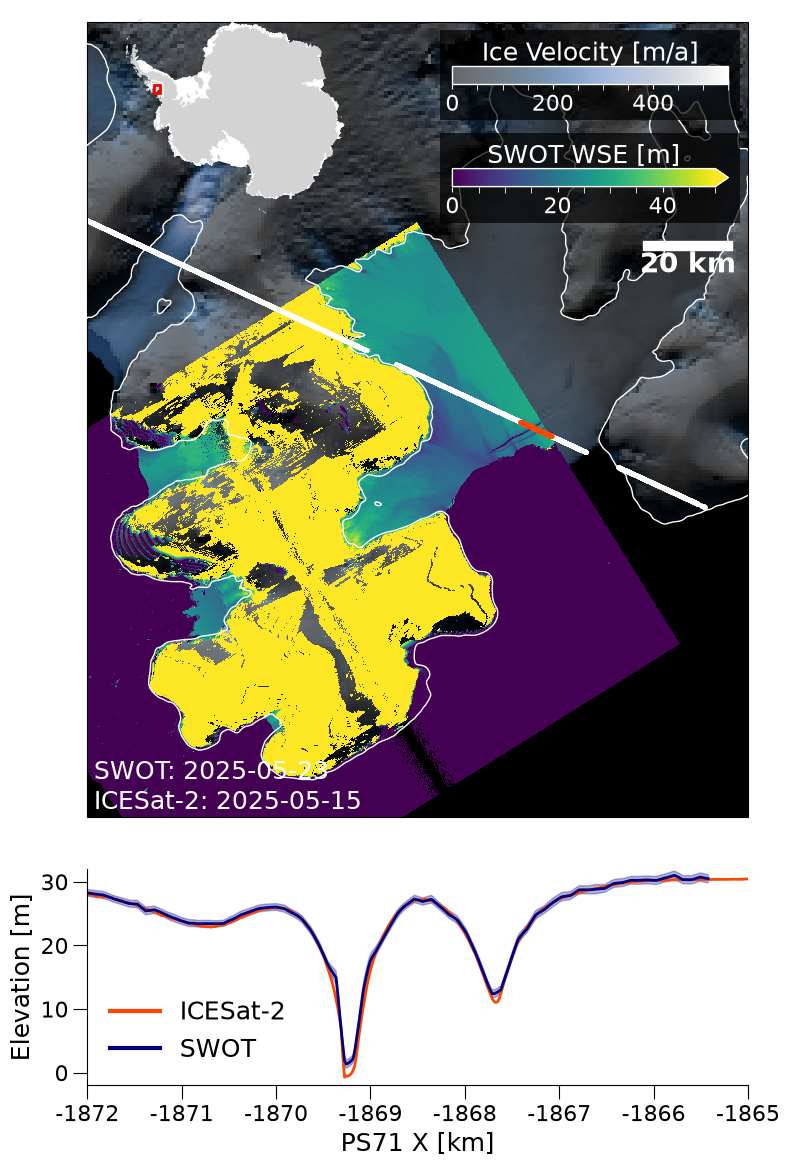

In [30]:
# Plot comparison
label = "Elevation [m]"
vmin = 0
vmax = 50

fig = plt.figure(figsize=(8, 12))

utm = ccrs.UTM(zone=ds_swot.utm_zone_num, southern_hemisphere=True)
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1])
ax = fig.add_subplot(gs[0], projection=ps71_projection)

# Map View
ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
cb = ax.imshow(vel_mag, cmap=oslo, 
               extent=[vel_mag["x"].min(), vel_mag["x"].max(), vel_mag["y"].min(), vel_mag["y"].max()],
               origin="upper", alpha=0.6, vmin=0, vmax=550)

grounded_3031.plot(ax=ax, transform=PS71, color="none", edgecolor="white", linewidth=1, zorder=4)

wse = ds_swot['wse']
x = wse["x"].values
y = wse["y"].values

X, Y = np.meshgrid(x, y)
mesh = ax.pcolormesh(X, Y, wse.values, transform=utm, cmap="viridis", shading="auto", vmin=vmin, vmax=vmax)

ax.scatter(data["x_advected"], data["y_advected"], color="white", s=5, transform=ps71_projection)

x_plotting = data["x_advected"][x_mask]
y_plotting = data["y_advected"][x_mask]
ax.scatter(x_plotting, y_plotting, color="orangered", s=5, transform=ps71_projection)

# Cross section
ax2 = fig.add_subplot(gs[1])

ax2.plot(data["x_advected"], data["is2_corrected"], 
         color="orangered", linewidth=2, label="ICESat-2")
ax2.plot(data["x_advected"], data["swot_corrected"],
         color="navy", linewidth=2, label="SWOT")
ax2.fill_between(data["x_advected"], data["swot_lower"], 
         data["swot_upper"], color="navy", alpha=0.3)

# SWOT Swath colorbar
add_inset_colorbar(fig, ax, mesh, label="SWOT WSE [m]", anchor=(0.999, 0.87), extend="max")

# Ice Velocity colorbar
add_inset_colorbar(fig, ax, cb, label="Ice Velocity [m/a]", anchor=(0.999, 0.999))

# Prettify panel 1
ax.set_xlim(BBOX[0] + 1000, BBOX[2] - 1000)
ax.set_ylim(BBOX[1] + 1000, BBOX[3] - 1000)

# Scalebar
scalebar = AnchoredSizeBar(ax.transData, 20000, "20 km", "lower right", pad=0.1, 
                           sep=1, color="white", frameon=False, size_vertical=2000,
                           fontproperties=mpl.font_manager.FontProperties(size=20, weight="bold"), label_top=False)

# Antarctica Inset
inset = fig.add_axes([0.15, 0.73, 0.3, 0.3], projection=ps71_projection)  # [left, bottom, width, height]
inset.patch.set_facecolor("none")
for spine in inset.spines.values():
    spine.set_visible(False)
inset.set_xticks([])
inset.set_yticks([])

grounded_3031.plot(ax=inset, transform=PS71, color="lightgray", edgecolor="lightgray", linewidth=0.3, zorder=1)
shelves_3031.plot(ax=inset,   transform=PS71, color="white", edgecolor="white", linewidth=0.3, zorder=2)

rect = plt.Rectangle((BBOX[0], BBOX[1]), BBOX[2] - BBOX[0], BBOX[3] - BBOX[1],
                     zorder=3, linewidth=2, edgecolor="red", facecolor="none")
inset.add_patch(rect)
ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, 0.67), transform=ax.transAxes)

# Time Labels
ax.text(0.01, 0.01, "SWOT: 2025-05-23\nICESat-2: 2025-05-15", transform=ax.transAxes, fontsize=legend_label_size, color="white")

# Polish panel 2
ax2.set_xlabel("PS71 X [km]", fontsize=legend_label_size)
ax2.set_ylabel("Elevation [m]", fontsize=legend_label_size)
KM_SCALE = 1e3
ticks_x = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax2.xaxis.set_major_formatter(ticks_x)
ax2.tick_params(axis="both", which="major", labelsize=tick_label_size, size=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_xlim(np.nanmin(data["x_advected"]), np.nanmax(data["x_advected"]))
ax2.set_xlim(min_mask, max_mask)  
ax2.set_ylim(-2, 32)

# Legend
handles = [
    Line2D([0], [0], color="orangered", linewidth=2, label="ICESat-2"),
    Line2D([0], [0], color="navy", linewidth=2, label="SWOT"),
    Patch(facecolor="navy", alpha=0.3, label="SWOT Uncertainty"),
]

ax2.legend(fontsize=legend_label_size, loc="lower left", handles=handles[:1] + [handles[1]])
leg = ax2.get_legend()
for line in leg.get_lines():
    line.set_linewidth(3)
leg.get_frame().set_edgecolor("white")
leg.get_frame().set_linewidth(1)

fig.tight_layout()
plt.show()

:::{tip} Summary
You loaded coincident SWOT HR and ICESat-2 ATL06, brought them to a comparable reference via geophysical corrections, advected the ICESat-2 track to SWOT time using a velocity map, and produced a plot comparing ICESat-2 and SWOT elevations over a rift on the Bach Ice Shelf.
:::

:::{tip} Glossary
Many of the functions used in this tutorial have names that are specific to satellite remote sensing. Below is a quick glossary explaining some of the commonly-used terms:

    atl06: ICESat-2 land ice height data product used for comparison
    
    Dynamic Atmosphere Correction (DAC): Response of ocean to atmospheric forcing
    
    Grounding Line: Transition from floating ice shelf to grounded ice
    
    ll: Latitude/Longiutde
    
    ps71xy: Polar Stereographic 71, the projection used for tutorial maps
    
    UTM: Universal Transverse Mercator, the coordinate system SWOT data is served in
:::

:::{error} 📝 Overall Conclusions
:icon: false
A summary panel recaps what was learned. 

Timing: This whole notebook took ~4 minutes to run, with no step taking longer than we needed to talk through the code, reducing downtime. This allows users to easily begin testing their use cases before scaling up to larger portions of datasets.

Excitement: The final plot is a striking image showing that two completley different satellites can both be corrected and measure the same elevation. This real-world application helps users feel accomplioshed and showcases that the tools used can used to perform meaningful science.
:::